In [1]:
import numpy as np 
import matplotlib.pyplot as plt

import sys 
sys.path.append('../../..')

from jax import config
config.update('jax_enable_x64', True)

from functools import partial
from jax import grad, jacfwd, vmap, jit, hessian, value_and_grad
from jax.lax import scan
# from jax.ops import index_update, index
import jax.random as jnp_random
import jax.numpy as np
import jax.debug as deb

from jax.flatten_util import ravel_pytree

import numpy as onp
from time_opt_erg_lib.dynamics import DoubleIntegrator, SingleIntegrator2D

from time_opt_erg_lib.ergodic_metric import ErgodicMetric
from time_opt_erg_lib.obstacle import Obstacle
from time_opt_erg_lib.cbf import constr2CBF
from time_opt_erg_lib.fourier_utils import BasisFunc, get_phik, get_ck
from time_opt_erg_lib.target_distribution import TargetDistribution
from time_opt_erg_lib.cbf_utils import sdf2cbf
from IPython.display import clear_output
import matplotlib.pyplot as plt

from opt_solver import AugmentedLagrangeSolver
import yaml
import pickle as pkl

def get_ck(trajectory, basis, tf, dt):
    ck = np.sum(vmap(basis.fk_vmap)(trajectory), axis=0)
    ck = ck/ck[0]
    ck = ck / basis.hk_list
    return ck

class ErgodicTrajOpt(object):
    def __init__(self, init_sol, args, scale, num_basis=5, step_size=1e-3, c=1.) -> None:
        basis           = BasisFunc(n_basis=[num_basis]*2)
        erg_metric      = ErgodicMetric(basis)
        robot_model     = DoubleIntegrator()
        n,m = robot_model.n, robot_model.m
        target_distr    = TargetDistribution()
        workspace_bnds = [[0.,1.0*scale],[0.,1.0*scale]]
    
        args.update({
            'phik' : get_phik(target_distr.evals, basis),
        })

        @vmap
        def emap(x):
            """ Function that maps states to workspace """
            return np.array([
                (x[0]-workspace_bnds[0][0])/(workspace_bnds[0][1]-workspace_bnds[0][0]), 
                (x[1]-workspace_bnds[1][0])/(workspace_bnds[1][1]-workspace_bnds[1][0])])
                
        # @jit
        def loss(params, args):
            # x = params['x']
            # u = params['u']
            tf = params['tf']
            # N = args['N']
            # dt = tf/N
            # e = emap(x)
            """ Traj opt loss function, not the same as erg metric """
            return tf

        def eq_constr(params, args):
            """ dynamic equality constriants """
            x = params['x']
            u = params['u']

            x0 = args['x0']
            xf = args['xf']
            tf = params['tf']
            N = args['N']
            dt = tf/N
            return np.vstack([
                (x[0] - x0), 
                x[1:,:]-(x[:-1,:]+dt*vmap(robot_model.dfdt)(x[:-1,:], u[:-1,:])),
                (x[-1] - xf)
            ])

        def ineq_constr(params, args):
            """ inequality constraints"""
            x = params['x']
            u = params['u']
            phik = args['phik']
            tf = params['tf']
            N = args['N']
            dt = tf/N
            e = emap(x)
            ck = get_ck(e, basis, tf, dt)
            _erg_ineq = [np.array([100.*(erg_metric(ck, phik) - args['erg_ub']), -tf])]
            _ctrl_box = [(np.abs(u) - 1.).flatten()]
            _expl_box = [(-e).flatten(), (e-1.0).flatten()]
            return np.concatenate(_erg_ineq + _ctrl_box + _expl_box)

        def compute_ergodic_metric(params, args):
            x = params['x']
            u = params['u']
            phik = args['phik']
            tf = params['tf']
            N = args['N']
            dt = tf/N
            e = emap(x)
            ck = get_ck(e, basis, tf, dt)
            return erg_metric(ck, phik)
    
        solver = AugmentedLagrangeSolver(
                        init_sol,
                        loss, 
                        eq_constr, 
                        ineq_constr, 
                        args, 
                        step_size=step_size,
                        c=c)
        self.solver = solver
        self.ineq_constr = ineq_constr
        self.eq_constr = eq_constr
        self.loss = loss
        self.compute_ergodic_metric = compute_ergodic_metric

In [2]:
# scales = [1., 10., 100., 1000.]
# scales = [100., 1000.]
scales = [1000.]

sols = []
t_init = np.array(12.)
for i, scale in enumerate(scales):
    args = {
        'N' : 50, 
        'x0' : np.array([0.1, 0.1, 0., 0.])*scale,
        'xf' : np.array([0.9, 0.9, 0., 0.])*scale,
        'erg_ub' : 0.01,
    }
    x = np.linspace(args['x0'], args['xf'], args['N'], endpoint=True)
    u = np.zeros((args['N'], 2))

    init_sol = {'x': x, 'u' : u, 'tf': np.array(20.)}
    traj_opt = ErgodicTrajOpt(init_sol, args, step_size=1e-2,scale=scale, c=0.1)
    traj_opt.solver.solve(max_iter=250_000, eps=0.65, alpha=1.000001)
    sol = traj_opt.solver.get_solution()
    sols.append(sol)
    print(sol['tf'], np.mean(traj_opt.eq_constr(sol, args)**2), np.mean(np.maximum(0,traj_opt.ineq_constr(sol, args))**2), traj_opt.compute_ergodic_metric(sol, args))


I0000 00:00:1715136525.530578       1 tfrt_cpu_pjrt_client.cc:349] TfrtCpuClient created.


KeyboardInterrupt: 

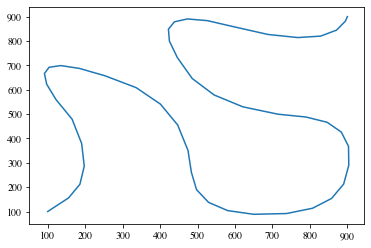

In [60]:
plt.plot(sol['x'][:,0], sol['x'][:,1])

# Scale Results

In [3]:
scales = [1, 10, 100, 1_000]
sols = []
t_init = np.array(12.)

for i, scale in enumerate(scales):
    args = {
        'N' : 50, 
        'x0' : np.array([0.1, 0.1, 0., 0.])*scale,
        'xf' : np.array([0.9, 0.9, 0., 0.])*scale,
        'erg_ub' : 0.01,
    }
    x = np.linspace(args['x0'], args['xf'], args['N'], endpoint=True)
    u = np.ones((args['N'], 2))

    init_sol = {'x': x, 'u' : u, 'tf': np.array(20.)}
    traj_opt = ErgodicTrajOpt(init_sol, args, step_size=1e-3,scale=scale)
    traj_opt.solver.solve(max_iter=250_000, eps=0.9, alpha=1.00001)
    if scale == 1000:
        traj_opt = ErgodicTrajOpt(init_sol, args, step_size=1e-2,scale=scale, c=0.1)
        traj_opt.solver.solve(max_iter=250_000, eps=0.65, alpha=1.000001)
    sol = traj_opt.solver.get_solution()
    sols.append(sol)
    print(sol['tf'], np.mean(traj_opt.eq_constr(sol, args)**2), np.mean(np.maximum(0,traj_opt.ineq_constr(sol, args))**2), traj_opt.compute_ergodic_metric(sol, args))


done in  33837  iterations
5.630272558821775 1.1726703846932886e-05 7.780253833576551e-07 0.010151105577591689
done in  9506  iterations
21.824295353160373 1.5934195072015701e-06 1.3815390077091347e-07 0.010048891281011885
done in  51574  iterations
70.14615860520549 3.986779768510884e-06 1.3378154078872464e-09 0.009342734146636545
done in  82713  iterations
done in  52918  iterations
243.2064823494775 0.001083064570096581 4.808401690374361e-05 0.01095842204395512


In [28]:
def plot_traj_one(_axs, sol, scale, time):

    _axs.set_title('Scale = {} \n Opt. Time = {:.2f}s'.format(scale, time))
    _axs.plot(sol['x'][:,0], sol['x'][:,1],'g.')
    _axs.plot(sol['x'][:,0], sol['x'][:,1])

    _axs.set_aspect('equal', 'box')
    _axs.set_xlim(0,scale)
    _axs.set_ylim(0,scale)
    _axs.set_yticks([0, 0.5*scale, 1*scale])
    _axs.set_xticks([0, 0.5*scale, 1*scale])

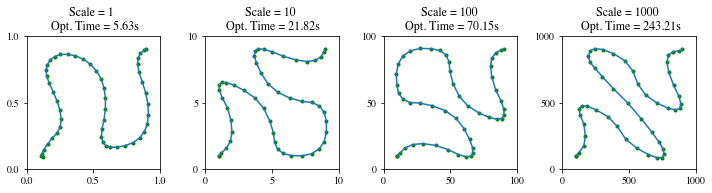

In [29]:
opt_times = [5.630272558821775, 21.824295353160373, 70.14615860520549, 243.2064823494775]
plt.rcParams["font.family"] = "times"

# fig, axs = plt.subplots(1, 2, figsize=(5,2))
fig, axs = plt.subplots(1, len(scales), figsize=(10,4))

for i, _sol in enumerate(sols):
    plot_traj_one(axs[i], _sol, scales[i], opt_times[i])
fig.tight_layout()

plt.savefig('scale_analysis.pdf')

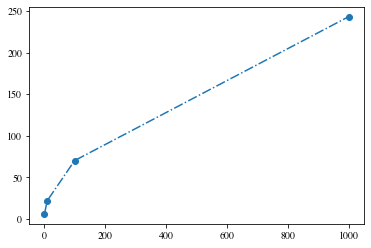

In [16]:
plt.plot(scales, opt_times, '-.o')

In [26]:
# plt.rcParams["font.family"] = "freeserif"
plt.rcParams["font.family"] = "times"

plt.figure(figsize=(3.5,2.2))
plt.errorbar(knots, np.array(avg_res)*1e3, yerr=np.array(std_res)*1e3, fmt='-.o')
plt.grid()
plt.xlabel('Control Knots')
plt.ylabel('Computation Time (ms) +- std')
# plt.legend()
plt.savefig('comp_anal.pdf')

NameError: name 'knots' is not defined

<Figure size 252x158.4 with 0 Axes>

Text(0, 0.5, 'Computation Time (ms) +- std')

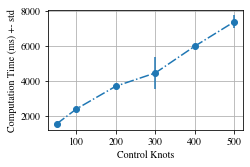

In [ ]:
plt.rcParams["font.family"] = "times"

plt.figure(figsize=(3.5,2.2))
plt.errorbar(knots, np.array(avg_res)*1e3, yerr=np.array(std_res)*1e3, fmt='-.o')
plt.grid()
plt.xlabel('Control Knots')
plt.ylabel('Computation Time (ms) +- std')

In [ ]:
num_basis = [5, 8, 10, 20, 50, 100]
avg_res = []
std_res = []
for i, _n_basis in enumerate(num_basis):
    args = {
        'N' : 100, 
        'x0' : np.array([0.1, 0.1, 0., 0.]),
        'xf' : np.array([0.9, 0.9, 0., 0.]),
        'erg_ub' : 0.1,
    }
    x = np.linspace(args['x0'], args['xf'], args['N'], endpoint=True)
    u = np.zeros((args['N'], 2))
    init_sol = {'x': x, 'u' : u, 'tf': np.array(10.0)}
    solver = build_erg_time_opt_solver(init_sol, args, num_basis=_n_basis)
    solver.solve(max_iter=1, eps=1e-7)
    _res = %timeit -o solver.solve(max_iter=1, eps=1e-7)
    avg_res.append(_res.average)
    std_res.append(_res.stdev)


126 µs ± 1.52 µs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)
219 µs ± 4.52 µs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
298 µs ± 6.97 µs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
850 µs ± 13.1 µs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
2.72 ms ± 186 µs per loop (mean ± std. dev. of 7 runs, 100 loops each)
10 ms ± 231 µs per loop (mean ± std. dev. of 7 runs, 100 loops each)


Text(0, 0.5, 'Computation Time (ms) +- std')

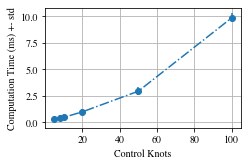

In [ ]:
plt.rcParams["font.family"] = "times"

plt.figure(figsize=(3.5,2.2))
plt.errorbar(num_basis, np.array(avg_res)*1e3, yerr=np.array(std_res)*1e3, fmt='-.o')
plt.grid()
plt.xlabel('Control Knots')
plt.ylabel('Computation Time (ms) +- std')

# Scale Result

In [ ]:
knots = [50, 200, 400, 600, 800, 1000]
knot_results = {
    'avg': [],
    'std': []}
for i, knot in enumerate(knots):
    args = {
        'N' : knot, 
        'x0' : np.array([0.1, 0.1, 0., 0.]),
        'xf' : np.array([0.9, 0.9, 0., 0.]),
        'erg_ub' : 0.1,
    }
    x = np.linspace(args['x0'], args['xf'], args['N'], endpoint=True)
    u = np.zeros((args['N'], 2))
    init_sol = {'x': x, 'u' : u, 'tf': np.array(10.0)}
    solver = build_erg_time_opt_solver(init_sol, args)
    _res = %timeit -o solver.solve(max_iter=1, eps=1e-7)
    knot_results['avg'].append(_res.average)
    knot_results['std'].append(_res.stdev)